In [1]:
import pandas as pd

In [2]:
import automated_marketmaker_calc.calc_v2 as calc_v2

# V2 application

In [3]:
calc_v2.PriceSim()

## Price sim

In [4]:
def process_bitcoin_csv(csv_path, dropNA=False):
    import pandas as pd

    df = pd.read_csv(csv_path, dtype=str)  # Read all columns as string

    # Convert Date to datetime
    df['Date'] = pd.to_datetime(df['Date'])

    # Remove commas and convert to float for price columns, keep NaN for missing values
    for col in ['Price', 'Open', 'High', 'Low']:
        df[col] = df[col].str.replace(',', '').replace('', None)
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Convert Vol. to numeric, handling 'k', 'M', and 'B' suffixes, keep NaN for missing values
    def parse_volume(val):
        if pd.isna(val) or val == '':
            return None
        val = str(val).replace(',', '').strip()
        if val.lower().endswith('k'):
            return float(val[:-1]) * 1_000
        elif val.lower().endswith('m'):
            return float(val[:-1]) * 1_000_000
        elif val.lower().endswith('b'):
            return float(val[:-1]) * 1_000_000_000
        try:
            return float(val)
        except ValueError:
            return None
    df['Vol.'] = df['Vol.'].apply(parse_volume)

    # Drop Change % column if exists
    if 'Change %' in df.columns:
        df = df.drop(columns=['Change %'])

    # Create Prices dataframe and reverse sequence
    prices_df = df[['Date', 'Open', 'High', 'Low', 'Price']].copy()
    prices_df = prices_df.rename(columns={'Price': 'Close'})
    prices_df = prices_df.sort_index(ascending=False).reset_index(drop=True).copy()

    # Create Volumes dataframe and reverse sequence
    volumes_df = df[['Date', 'Vol.']].copy()
    volumes_df = volumes_df.rename(columns={'Vol.': 'Volume'})
    volumes_df = volumes_df.sort_index(ascending=False).reset_index(drop=True).copy()

    # Optionally drop NA and print number of dropped rows
    if dropNA:
        before_prices = len(prices_df)
        before_volumes = len(volumes_df)
        prices_df = prices_df.dropna().reset_index(drop=True)
        volumes_df = volumes_df.dropna().reset_index(drop=True)
        print(f"Dropped {before_prices - len(prices_df)} rows from prices_df due to NA values.")
        print(f"Dropped {before_volumes - len(volumes_df)} rows from volumes_df due to NA values.")

    return prices_df, volumes_df

prices_df, volumes_df = process_bitcoin_csv('./data/Bitcoin Historical Data.csv', dropNA=True)

Dropped 0 rows from prices_df due to NA values.
Dropped 6 rows from volumes_df due to NA values.


In [5]:
def process_ethereum_csv(csv_path, cols=None, dropNA=False):
    import pandas as pd

    # read everything as string so we can clean it up uniformly
    df = pd.read_csv(csv_path, dtype=str)

    # if a column mapping is provided, rename from the raw csv names -> our
    # standard column names.  The user passes a dict where the *keys* are the
    # standard names and the *values* are the names that actually appear in the
    # CSV.  For example:
    #     {"Date": "snapped_at", "Price": "price",
    #      "Volume": "total_volume"}
    # We invert the mapping so that pandas.rename() can do the right thing.
    if cols:
        inv_map = {csv_name: std_name for std_name, csv_name in cols.items()}
        df = df.rename(columns=inv_map)

    # Convert Date to datetime if present
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])

    # Clean up any price‑like fields; if they don't exist we just skip them.
    for col in ['Price', 'Open', 'High', 'Low']:
        if col in df.columns:
            df[col] = df[col].str.replace(',', '').replace('', None)
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Convert volume field if it exists
    if 'Volume' in df.columns:
        def parse_volume(val):
            if pd.isna(val) or val == '':
                return None
            val = str(val).replace(',', '').strip()
            if val.lower().endswith('k'):
                return float(val[:-1]) * 1_000
            elif val.lower().endswith('m'):
                return float(val[:-1]) * 1_000_000
            elif val.lower().endswith('b'):
                return float(val[:-1]) * 1_000_000_000
            try:
                return float(val)
            except ValueError:
                return None
        df['Volume'] = df['Volume'].apply(parse_volume)

    # Drop Change % column if exists
    if 'Change %' in df.columns:
        df = df.drop(columns=['Change %'])

    # Build prices dataframe using only the columns that survived
    price_cols = ['Date'] + [c for c in ['Open', 'High', 'Low', 'Price'] if c in df.columns]
    prices_df = df[price_cols].copy()
    if 'Price' in prices_df.columns:
        prices_df = prices_df.rename(columns={'Price': 'Close'})
    # prices_df = prices_df.sort_index(ascending=False).reset_index(drop=True).copy()

    # Build volumes dataframe if we have a volume column, otherwise make an empty
    # frame with the expected columns so the return type is consistent.
    if 'Volume' in df.columns:
        volumes_df = df[['Date', 'Volume']].copy()
        # volumes_df = volumes_df.sort_index(ascending=False).reset_index(drop=True).copy()
    else:
        volumes_df = pd.DataFrame(columns=['Date', 'Volume'])

    # Optionally drop NA and print number of dropped rows
    if dropNA:
        before_prices = len(prices_df)
        before_volumes = len(volumes_df)
        prices_df = prices_df.dropna().reset_index(drop=True)
        volumes_df = volumes_df.dropna().reset_index(drop=True)
        print(f"Dropped {before_prices - len(prices_df)} rows from prices_df due to NA values.")
        print(f"Dropped {before_volumes - len(volumes_df)} rows from volumes_df due to NA values.")

    return prices_df, volumes_df

# example usage (the call below is still pointing at bitcoin by mistake –
# update it later if you actually use ethereum data)

cols = {"Date": "snapped_at", "Price": "price", "Volume": "total_volume"}

prices_df, volumes_df = process_ethereum_csv('./data/eth-usd-max.csv', cols=cols, dropNA=True)

Dropped 0 rows from prices_df due to NA values.
Dropped 0 rows from volumes_df due to NA values.


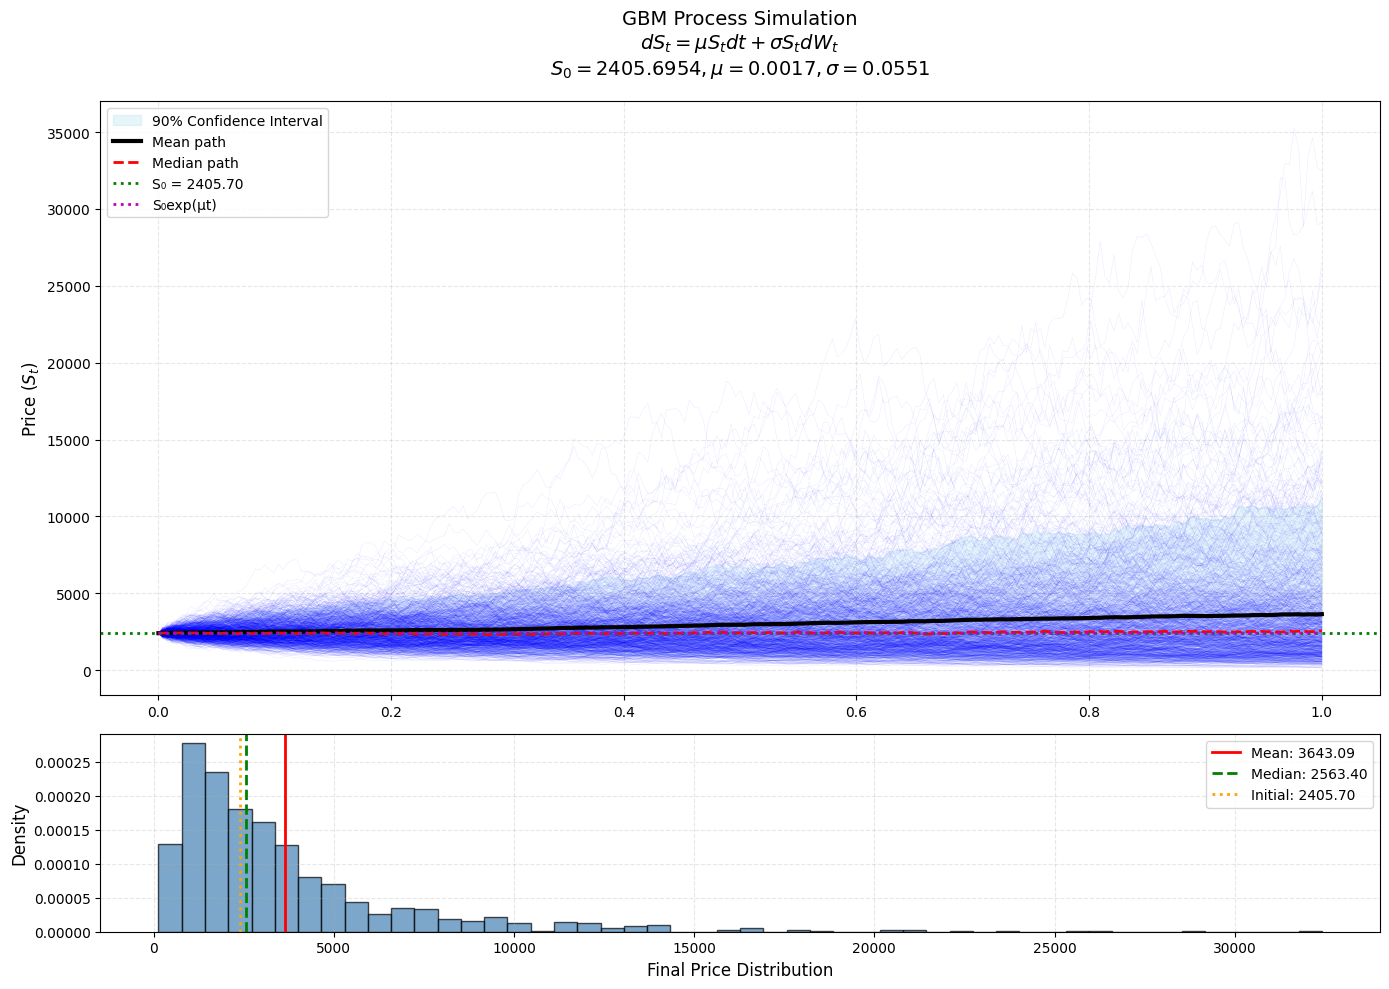

In [6]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Create sample data if you don't have a CSV
dates = prices_df['Date']  # Use dates from the processed DataFrame
prices = prices_df['Close'].values  # Use actual prices from the processed DataFrame

sample_data = pd.DataFrame({
    'Date': dates,
    'Adj Close': prices
})

# Run simulation
price_simulator = calc_v2.PriceSim()
simulated_prices = price_simulator.pipeline(
    n_paths = 1000,
    predicted_period=252,      # 60-day forecast
    FX_data=sample_data,      # Use our sample data
    backtesting=True,
    plot_sim=True
)

## Volume sim

VOLUME SIMULATION RESULTS
Input data points: 3858
Input mean volume: 12,385,646,373
Input volume std: 13,809,760,938

Simulation parameters:
  - θ (mean reversion): 5
  - μ (long-term mean): 12,385,646,373
  - σ (volatility): 13,809,760,938

Simulation output:
  - Shape: (253, 1000) (days × paths)
  - First simulated path mean: 11,841,285,920


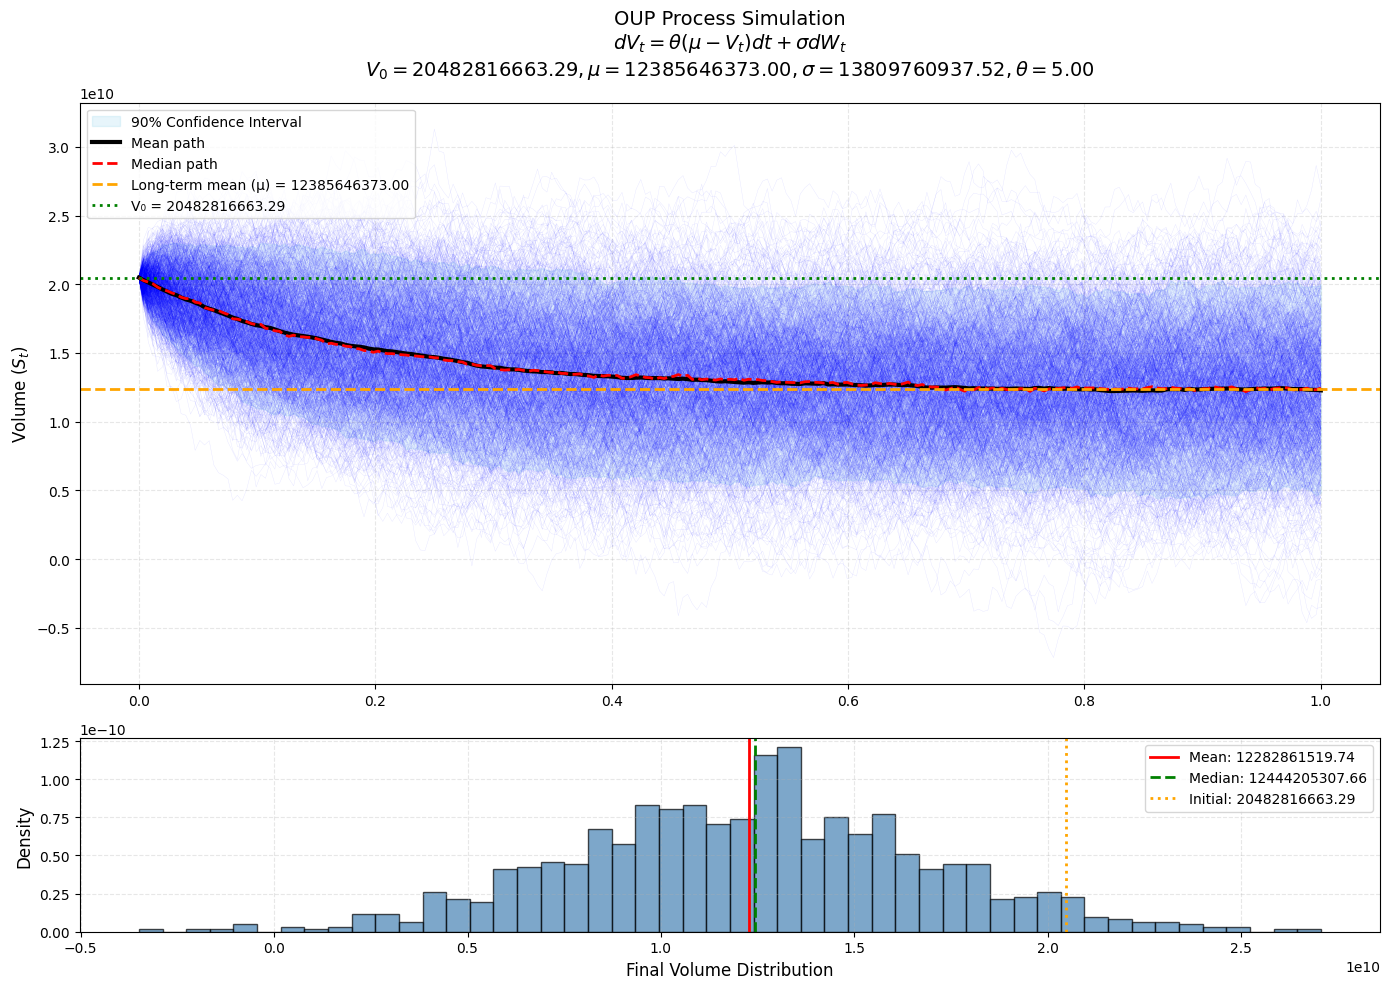

In [7]:
import pandas as pd
import numpy as np

# 1. Create or load volume data
# If you have a CSV:

volume_series = pd.Series(
    volumes_df['Volume'].values,
    index= volumes_df['Date'],
    name='Volume'
)

# Or create sample data:
# dates = volumes_df['Date'] # pd.date_range(start='2020-01-01', end='2023-12-31', freq='D')
# volume_series = pd.Series(
#     np.random.lognormal(14, 0.5, len(dates)),  # Log-normal distribution typical for volumes
#     index=dates,
#     name='Volume'
# )


# 2. Run volume simulation
volume_sim = calc_v2.VolumeSim()
simulated_volumes = volume_sim.pipeline(
    theta=5,            # Mean reversion speed
    n_paths = 1000,
    volume=volume_series,
    predicted_period=252,    # 30-day forecast
    backtesting=True
)

# 3. Analyze results
print("="*50)
print("VOLUME SIMULATION RESULTS")
print("="*50)
print(f"Input data points: {len(volume_series)}")
print(f"Input mean volume: {volume_series.mean():,.0f}")
print(f"Input volume std: {volume_series.std():,.0f}")
print(f"\nSimulation parameters:")
print(f"  - θ (mean reversion): {volume_sim.theta}")
print(f"  - μ (long-term mean): {volume_sim.mu:,.0f}")
print(f"  - σ (volatility): {volume_sim.sigma:,.0f}")
print(f"\nSimulation output:")
print(f"  - Shape: {simulated_volumes.shape} (days × paths)")
print(f"  - First simulated path mean: {simulated_volumes[0].mean():,.0f}")

# volume_sim.plot_UOP_paths(sim_df = simulated_volumes, 
#                      predicted_period = 30, backtesting = True)

volume_sim.unified_plot(sim_df = simulated_volumes, predicted_period=252, backtesting = True)

## Payoff calc v2.0

In [8]:
import math
fx = simulated_prices.at[0,0]
k = 10000

y = math.sqrt(k / fx)
x = math.sqrt(k * fx)

print(f"Initial FX: {fx:,.2f}, Initial X: {x:,.2f}, Initial Y: {y:,.2f}")

Initial FX: 2,405.70, Initial X: 4,904.79, Initial Y: 2.04


In [9]:
from automated_marketmaker_calc.calc_v2 import Payoff

# Example parameters (adjust as needed)
pool_fee = 0.01
amount_x_pool_t0 = x
amount_y_pool_t0 = y
total_investment_x = 100
max_paths = 100
fee_split = 1.0  # 50/50 fee split between X and Y (subject to exchange rate risk)
captured_volumes = simulated_volumes * 0.0000001  # Adjusted volumes

# Instantiate the Payoff class
payoff = Payoff()

# Run the pipeline
# NOTE: deposit_split_percentage is now FIXED at 0.5 internally
# The pool ratio is defined by amount_x_pool_t0 and amount_y_pool_t0
payoff.pipeline(
    pool_fee=pool_fee,
    amount_x_pool_t0=amount_x_pool_t0,
    amount_y_pool_t0=amount_y_pool_t0,
    total_investment_x=total_investment_x,
    FX_timeseries=simulated_prices,
    volume_timeseries=captured_volumes,
    max_paths=max_paths,
    fee_split=fee_split,                    # New parameter: controls fee allocation
    use_volume_decomposition=True,         # Set to True if you want volume decomposition
    drop_insufficient_volume=False          # Set to True to drop paths with insufficient volume
)

# Access results
print(payoff.paths_df.head())

Progress: 100/100 paths processed

Processing complete. Total paths: 100
   sim                                                dfs
0    0                FX  pool_fee       volume  pool_...
1    1                FX  pool_fee       volume  pool_...
2    2                FX  pool_fee       volume  pool_...
3    3                FX  pool_fee       volume  pool_...
4    4                FX  pool_fee       volume  pool_...


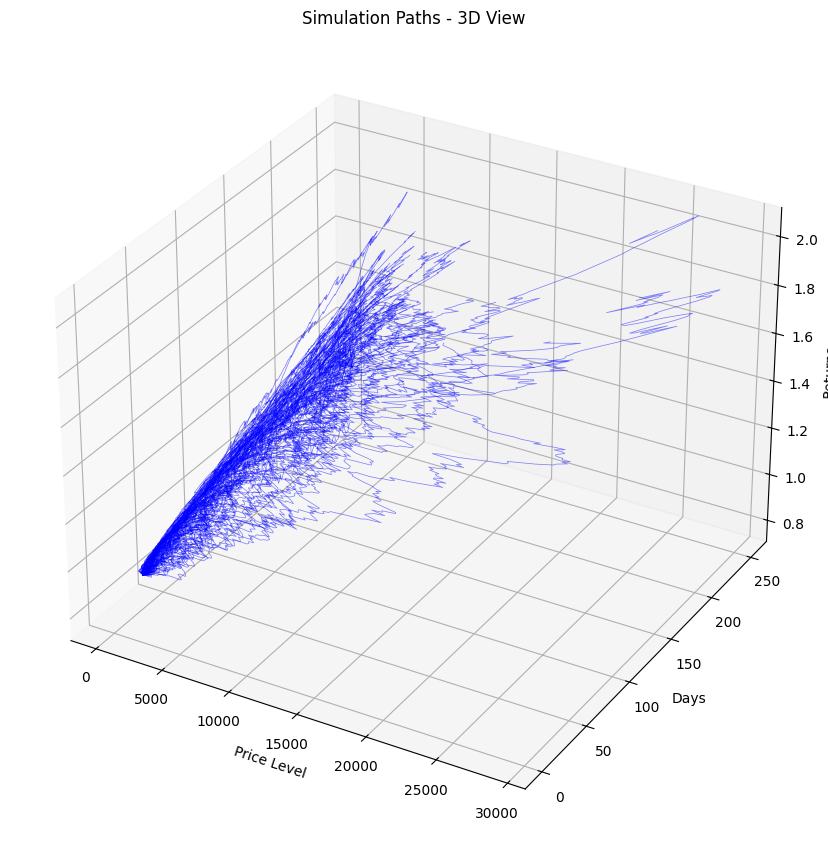

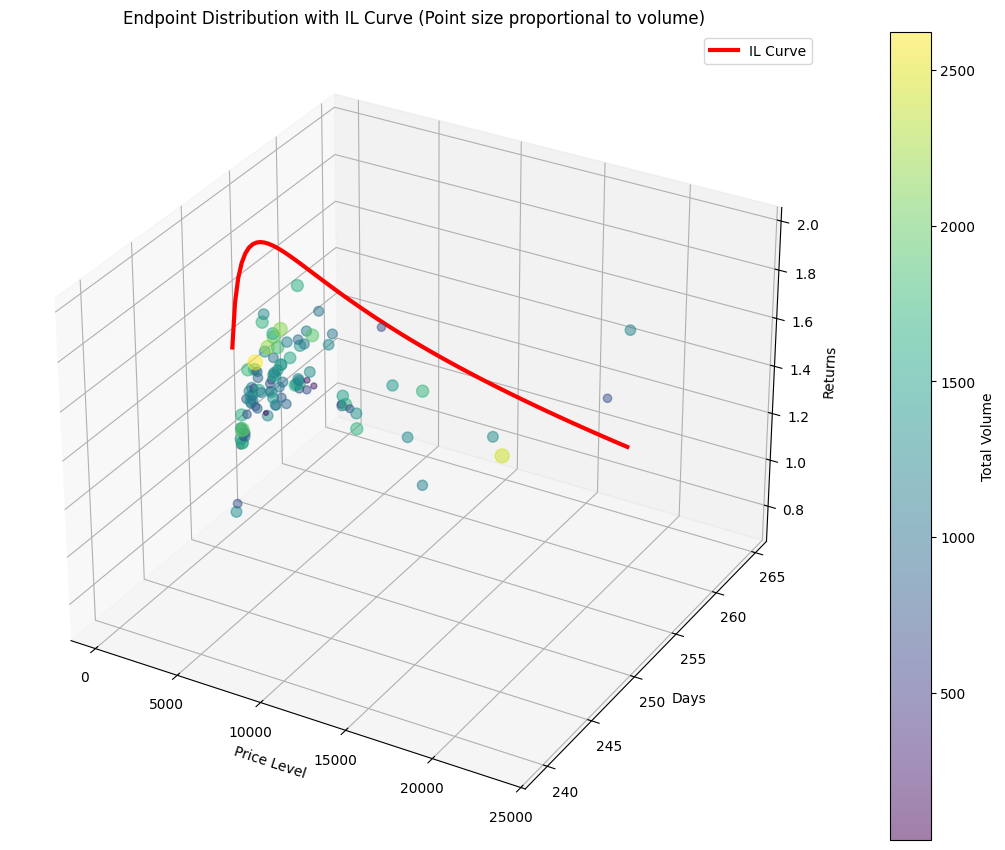

SIMULATION SUMMARY STATISTICS

1. Endpoint Statistics:
           cum_II  cum_II_netto            FX  V_total_vol  V_required_vol  \
count  100.000000    100.000000    100.000000   100.000000      100.000000   
mean     1.426793      1.341347   3948.554119  1207.812761      143.406364   
std      0.194032      0.192034   4126.088920   473.087188      131.501355   
min      1.162664      0.735559    193.649174    26.816240        1.012057   
25%      1.294681      1.247215   1455.971426   894.514674       43.302313   
50%      1.392182      1.347263   2761.899132  1211.001585       99.229505   
75%      1.495014      1.436855   4660.054731  1513.787200      202.573669   
max      2.385242      1.965282  23544.002797  2623.996181      815.901108   

       V_required_y_vol  V_excess_vol  
count        100.000000    100.000000  
mean           0.062287   1065.762493  
std            0.073409    486.493325  
min            0.000726      0.000000  
25%            0.019924    722.818481  
50

In [10]:
# Assuming you have already run the payoff pipeline and have payoff.paths_df and payoff.pool_performance

# Import the Visualization class if not already imported
from automated_marketmaker_calc.calc_v2 import Visualization

# Instantiate Visualization with the paths DataFrame and pool performance DataFrame
viz = Visualization(
    paths_df=payoff.paths_df,
    pool_performance=payoff.pool_performance,
    dropped_paths_log=getattr(payoff, 'dropped_paths_log', None)  # Optional, if available
)

# Show 3D path plot
viz.path_plot(show_volume_decomposition=False)  # Set to True if you want to color by volume sufficiency

# Show endpoint distribution plot
viz.endpoint_plot(show_volume_size=True)  # Set to True to size points by volume

# If you used volume decomposition, you can also plot volume decomposition analysis
# viz.volume_decomposition_plot()

# Print summary statistics
viz.summary_statistics()

In [12]:
single_path = payoff.paths_df['dfs'].at[0]

In [13]:
import matplotlib.pyplot as plt

In [17]:
single_path['k_pool'].iloc[0]

np.float64(10204.92157274411)

In [18]:
single_path['k_pool'].iloc[-1]

np.float64(19760.089760648138)

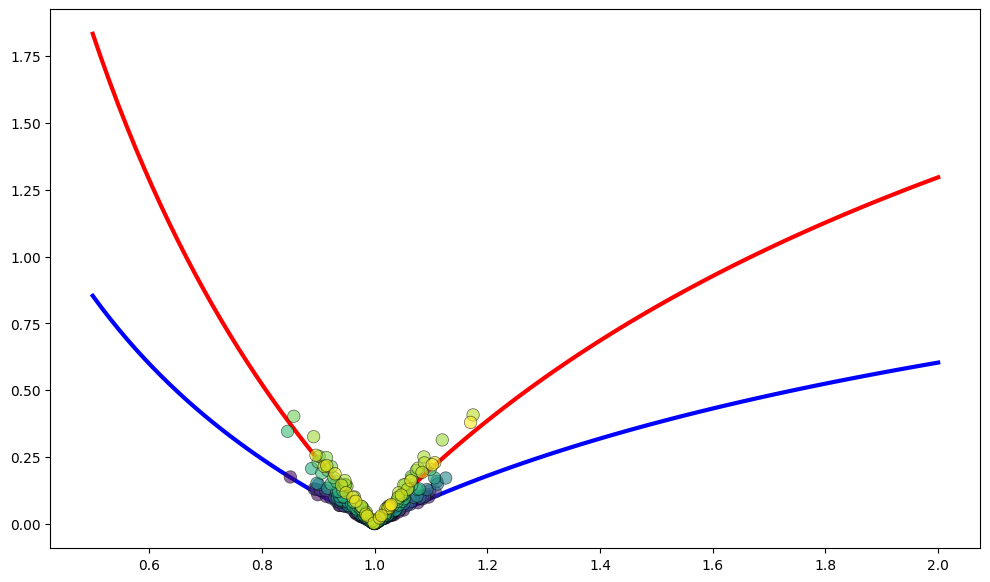

In [16]:
import matplotlib.pyplot as plt

single_path = payoff.paths_df['dfs'].at[0]

single_path['FX_ratio_diff'] = single_path['FX']/single_path['FX'].shift(1)

# price_ratios = np.linspace(single_path['FX_ratio_diff'].min(), single_path['FX_ratio_diff'].max(), num=100)
price_ratios = np.linspace(0.5, 2, num=100)
y0 = single_path['amount_y_pool'].iloc[0] # Assuming initial price ratio is at index 0
ytn = single_path['amount_y_pool'].iloc[-1] # Assuming final price ratio is at the last index

V_bound = y0 * np.abs(1 - 1.0 / np.sqrt(price_ratios))

V_bound_tn = ytn * np.abs(1 - 1.0 / np.sqrt(price_ratios))

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(price_ratios, V_bound,
'b-', linewidth=3, label='Theoretical Volume Bound (Step-wise)', zorder=3)
ax.plot(price_ratios, V_bound_tn,
'r-', linewidth=3, label='Theoretical Volume Bound (Final)', zorder=3)
ax.scatter(single_path['FX_ratio_diff'], single_path['V_required_y_vol'],
s=80, alpha=0.6, c=np.arange(len(single_path['FX_ratio_diff'])),
cmap='viridis', edgecolors='black', linewidth=0.5,
label='Simulation Steps', zorder=4)

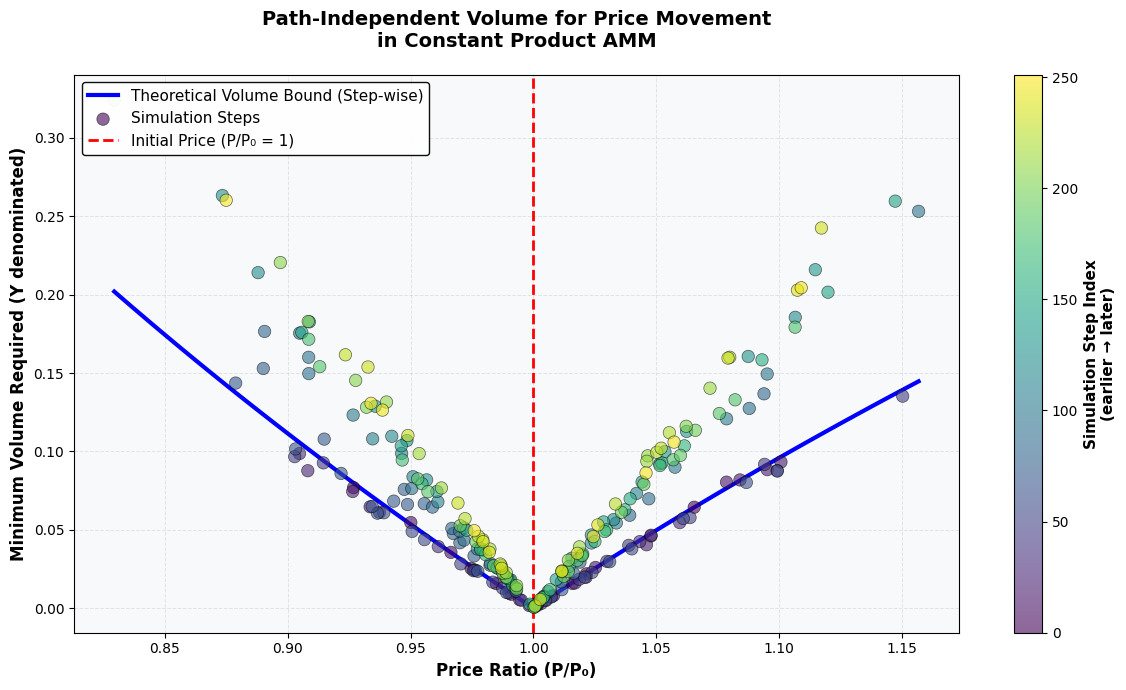

In [14]:
from automated_marketmaker_calc.volume_visualization import plot_volume_bound

# Get the first path from simulation results
single_path = payoff.paths_df['dfs'].at[0]

# Create the volume bound visualization
fig, ax = plot_volume_bound(single_path)
plt.show()
